<a href="https://colab.research.google.com/github/shagun30107-bit/csot-ml-astronomy/blob/main/Astronony(Part_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PART-2:Data Pipeline**

# STEP-0

In [ ]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)



Using: cuda


# STEP-1

In [ ]:
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"


!pip install -q kaggle
# Kaggle authentication
os.environ["KAGGLE_API_TOKEN"] = "KGAT_3f3d786e5f471c9718d9cc3a6e481eb9"

# Download Galaxy Zoo 2 dataset
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p galaxy_raw

# Extract dataset
!unzip -q -o galaxy_raw/galaxy-zoo-2-images.zip -d {RAW_ROOT}

# !unzip -q -o {RAW_ROOT}/images_gz2.zip -d {IMAGES_DIR}

# Download Hart et al. labels
!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz


Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
galaxy-zoo-2-images.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# !unzip -q -o galaxy_raw/galaxy-zoo-2-images.zip -d galaxy_raw

# STEP-2

In [ ]:
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)
print(mapping_head)

RAW_ROOT contents: ['galaxy-zoo-2-images.zip', 'gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3


# STEP-3 {WORST STEP--I just copy n paste it}



In [ ]:
def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 morphology codes to a few training buckets."""
    if not gz2_class or gz2_class == "A":
        return None  # artifact / ambiguous — skip
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    """Symlink a balanced subset into out_root// for ImageFolder."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts

PER_CLASS = 200  # balanced subset — fast on Colab; increase once the pipeline works
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

Symlinked per class: {'elliptical': 200, 'spiral': 200, 'spiral_barred': 200}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


# STEP-4

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# STEP-5

In [ ]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(root=DATA_ROOT, transform=transform)

print(len(dataset))          # number of training images
print(dataset.classes)
print(dataset.class_to_idx)

600
['elliptical', 'spiral', 'spiral_barred']
{'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


# STEP-6

In [ ]:
image, label = dataset[0]    # one sample
print(image.shape,image.dtype, label)
print(dataset.classes[label])

torch.Size([3, 64, 64]) torch.float32 0
elliptical


# STEP-7

In [ ]:
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

for images, labels in loader:
  print("Images:", images.shape)
  print("Labels:", labels.shape)
  break

Images: torch.Size([32, 3, 64, 64])
Labels: torch.Size([32])


# STEP-7

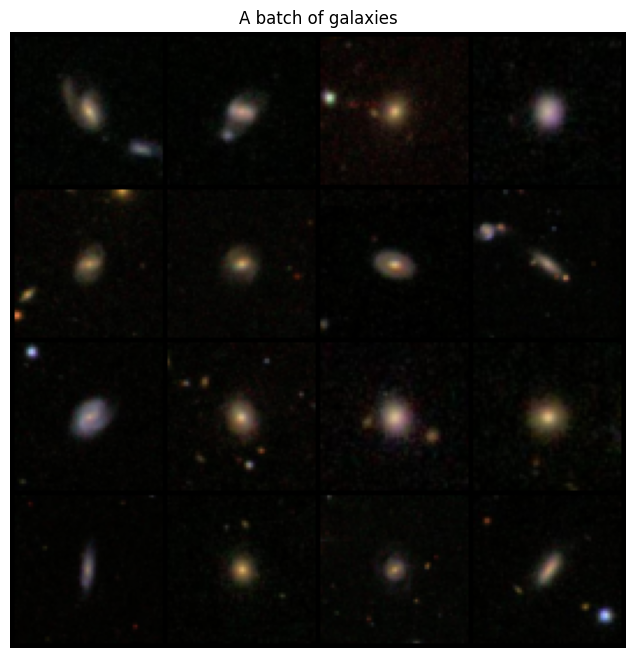

Labels: ['spiral_barred', 'spiral_barred', 'elliptical', 'elliptical', 'spiral_barred', 'spiral_barred', 'spiral', 'elliptical', 'spiral_barred', 'elliptical', 'elliptical', 'elliptical', 'spiral', 'elliptical', 'spiral_barred', 'spiral']


In [ ]:
import matplotlib.pyplot as plt
import torchvision

images, labels = next(iter(loader))

images_show = images * 0.5 + 0.5

grid = torchvision.utils.make_grid(images_show[:16], nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("A batch of galaxies")
plt.show()

print("Labels:", [dataset.classes[i] for i in labels[:16].tolist()])

# **`REFLECTION`**

1.  The most confusing part was uploading the file. I spent a lot of time trying to figure it out. Firstly, that Hart16 file wasn't downloading, and after it finally downloaded, I struggled to upload it correctly. Even after trying multiple times, it kept showing errors. and in the last, I copied the code from the sol. and used ChatGPT to help me debug the remaining issues. After that, all the errors were resolved.<br>
I also didn't understand what we were supposed to do in Step 3, so I ended up copying that part as well.
2.   A CNN can identify a lenticular (S0) galaxy by looking for a galaxy that has a clear disk and bright center like a spiral galaxy, but without any visible spiral arms or active star-forming regions.

3. spiral & spiral_barred...bothe of them looking same
4. **Model is secondary; the data pipeline comes first.** A small data issue, such as wrong labels, incorrect normalization, or data leakage, can hurt model performance without showing any errors, so it's imp. to get the data right before building the model.


